In [10]:
%load_ext autoreload
%autoreload 2

import numpy as np
import xarray as xr
import pandas as pd
import regionmask as rm
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib.colors import BoundaryNorm
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import sys
module_path = "../bin"
sys.path.insert(0,module_path)

import um_utils_plotting as umplt
import um_utils as um
from geometry_fix import apply_geometry_collection_fix

apply_geometry_collection_fix()

np.set_printoptions(suppress=True)

um.WarningSuppress()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


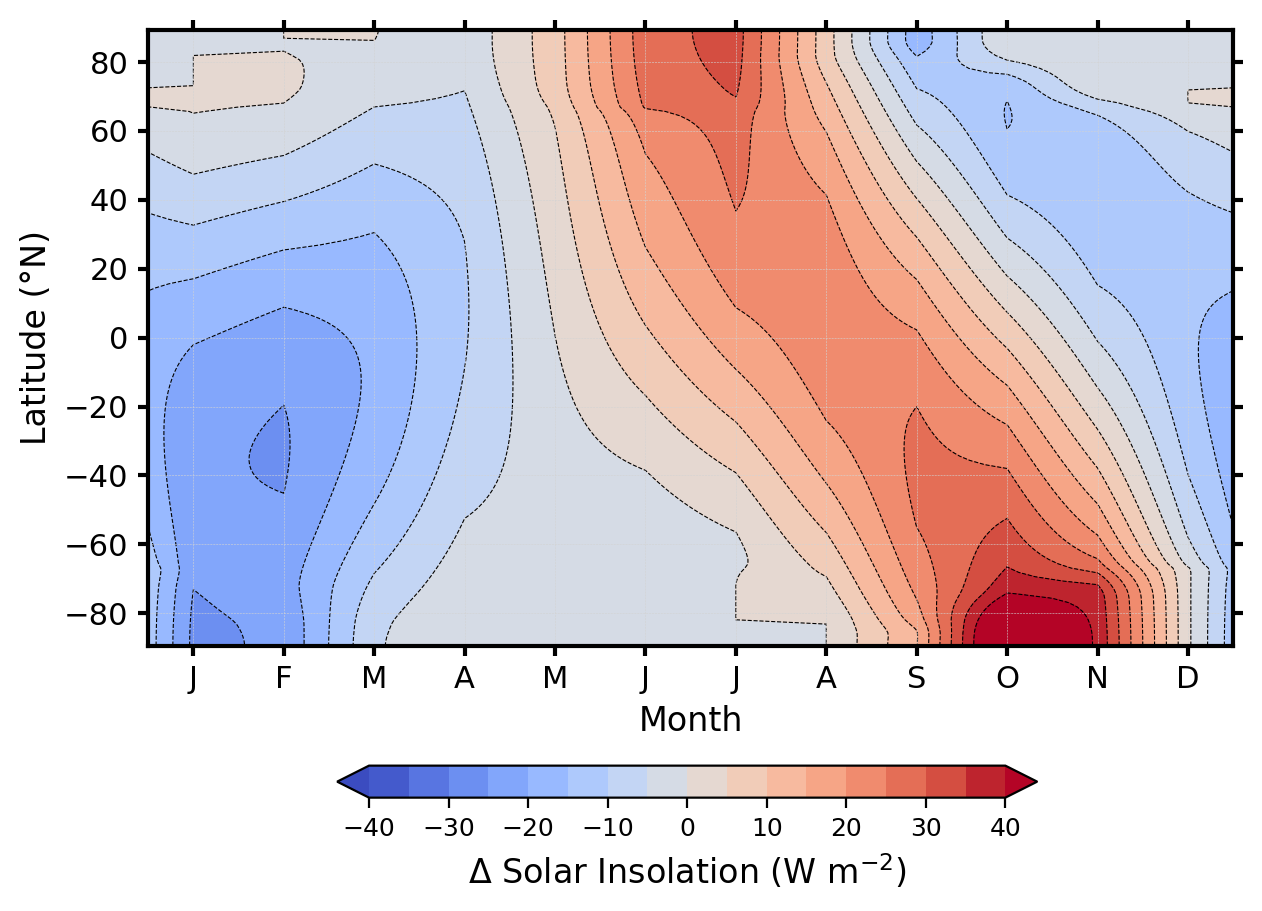

In [ ]:
#------------------------------------------------------------
# Fig. S1: Insolation Anomaly
#------------------------------------------------------------

MH_means = um.importUMData("../Data/Models/Monthly_Means/MH_monthly_means_197001-204912.nc")
PI_means = um.importUMData("../Data/Models/Monthly_Means/PI_monthly_means_187001-194912.nc")

plt_time = np.arange(14)
xticklabs = ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]

cmap = cm.coolwarm; v = 40; levs = np.linspace(-v, v, 17); cbar_lab = r"$\Delta$ Solar Insolation (W $\mathregular{m^{-2}}$)"

del_sw_in = (MH_means['toa_sw_in'] - PI_means['toa_sw_in']).mean(dim="longitude").transpose()
del_sw_in = xr.concat(
    [del_sw_in.isel(time=-1), del_sw_in, del_sw_in.isel(time=0)], dim="time"
)

fig, ax = plt.subplots(figsize = (7, 4), dpi=200)

f1 = ax.contourf(plt_time, del_sw_in.latitude, del_sw_in, extend="both", cmap=cmap, levels=levs, zorder=0)
c1 = ax.contour(plt_time, del_sw_in.latitude, del_sw_in, extend="both", colors="k", linestyles="dashed", linewidths=0.4, levels=levs, zorder=0)

ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Latitude (°N)", fontsize=12)
ax.set_xticks(np.arange(1, 13), labels=xticklabs)
ax.set_xlim((0.5, 12.5))
ax.xaxis.set_ticks_position("both")
ax.yaxis.set_ticks_position("both")
ax.grid(True, color="lightgrey", ls="--", lw=0.2, zorder=10)
ax.tick_params("both", width=1.5, labelsize=11)

cbaxes = fig.add_axes((0.26, -0.08, 0.5, 0.04))
cbar = plt.colorbar(f1, extend='both', orientation='horizontal', ticks=levs[::2], cax=cbaxes)
cbar.ax.tick_params(labelsize=9) 
cbar.set_label(label=cbar_lab, size=12)

for spine in ["top", "bottom", "left", "right"]:
    ax.spines[spine].set_linewidth(1.5)

plt.show()

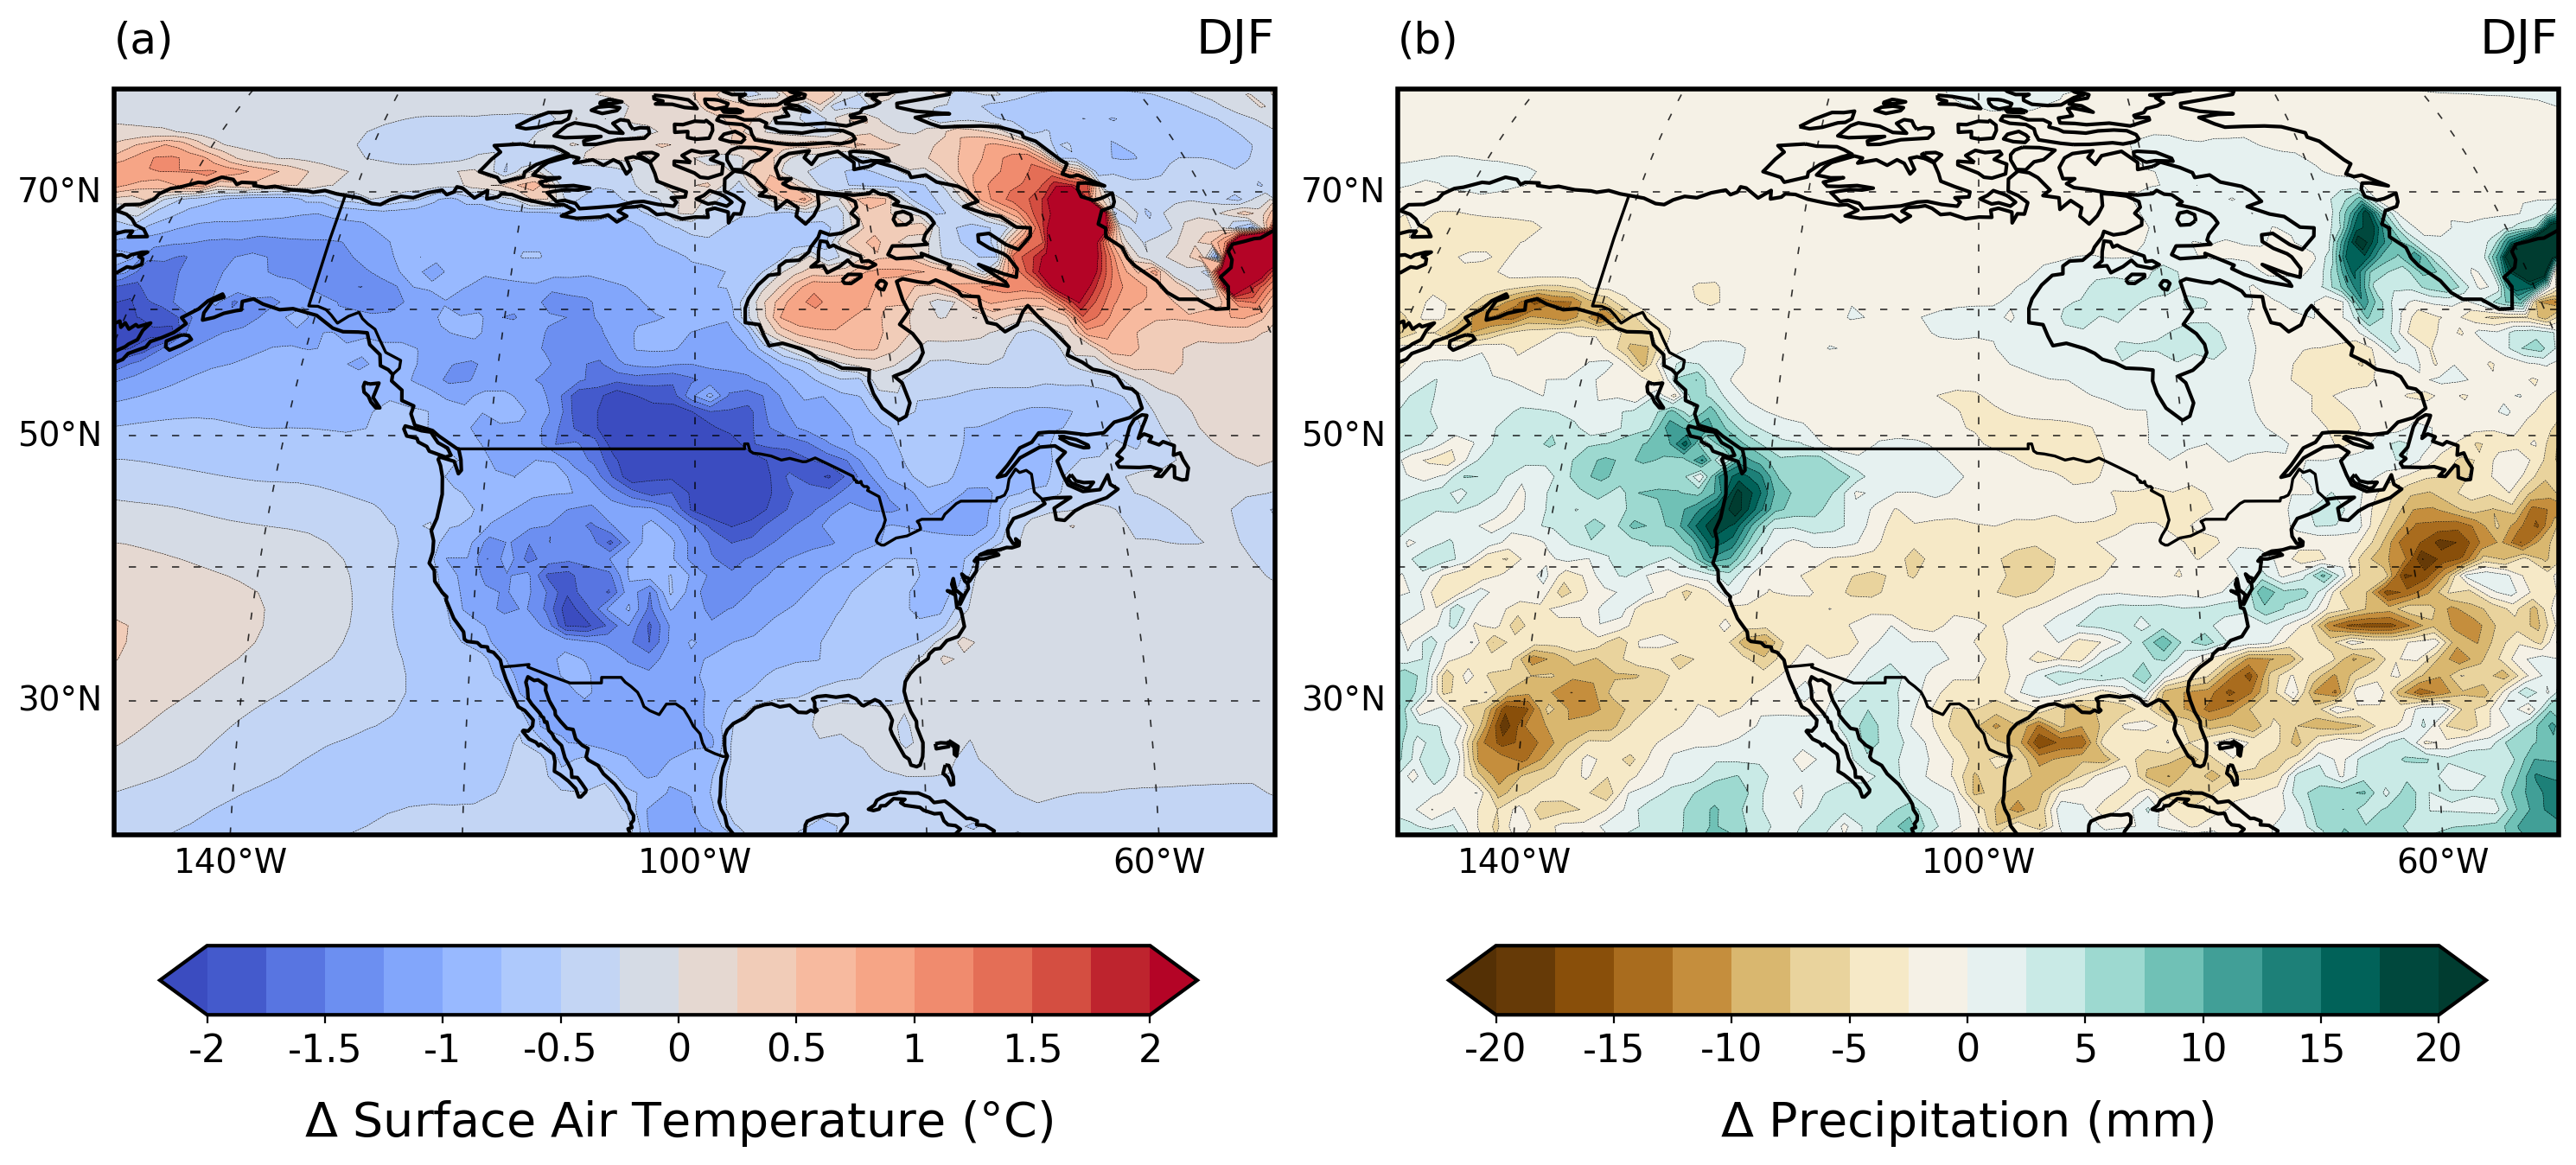

In [ ]:
#------------------------------------------------------------
# Fig. S2: DJF Climate Anomalies
#------------------------------------------------------------

MH_means = um.importUMData(f"../Data/Models/Monthly_Means/MH_monthly_means_197001-204912.nc")
PI_means = um.importUMData(f"../Data/Models/Monthly_Means/PI_monthly_means_187001-194912.nc")
LON, LAT = np.meshgrid(MH_means.longitude, MH_means.latitude)

vars = ["tas", "pr"]
labels = np.array(["a", "b"])
period_data = ("DJF", [11, 0, 1])

fig = plt.figure(figsize = (15, 8), dpi=200)
gs = gridspec.GridSpec(1, 2)

lims, proj = [-150, -50, 20, 80], ccrs.Robinson(central_longitude=-100)

for i, var in enumerate(vars):
    if var == "tas":
        cmap = cm.coolwarm; v = 2; levs = np.linspace(-v, v, 17); cbar_lab = r"$\Delta$ Surface Air Temperature (°C)"
        norm = BoundaryNorm(levs ,cmap.N ,extend="both")
        cbaxes = fig.add_axes((0.065, 0.1, 0.4, 0.05))

    elif var == "pr":
        cmap = cm.BrBG; v = 20; levs = np.linspace(-v, v, 17); cbar_lab = r"$\Delta$ Precipitation (mm)"
        norm = BoundaryNorm(levs, cmap.N, extend="both")
        cbaxes = fig.add_axes((0.562, 0.1, 0.4, 0.05))

    modelAnom = MH_means[var] - PI_means[var]

    period = period_data[0]
    months = period_data[1]

    ax = plt.subplot(gs[i], projection=proj)    
    umplt.plotBaseMap(ax, lims, coastlw=1.5, spinelw=2, bordercol="black", borderlw=1.2)
    umplt.plotGrid(ax, xlabeledlines=[-60, -100, -140], ylabeledlines=[30, 50, 70],
                   xlines=[-40, -80, -120, -160], ylines=[40, 60], labelsize=14, lw=0.6)
    
    modelAnom_mon = modelAnom.isel(time=months).mean(dim="time")

    cf1 = ax.contourf(LON, LAT, modelAnom_mon, extend="both", levels=levs, cmap=cmap, transform=ccrs.PlateCarree(), transform_first=True, zorder=0)
    c1 = ax.contour(LON, LAT, modelAnom_mon, extend="both", levels=levs, colors="black", linestyles="dashed", linewidths=0.2, transform=ccrs.PlateCarree(), transform_first=True, zorder=0)

    cbar = plt.colorbar(cf1, extend='both', orientation='horizontal', ticks=np.linspace(-v, v, 9), cax=cbaxes)
    cbar.outline.set_linewidth(1.5)
    cbar.set_ticks(np.linspace(-v, v, 9), labels=["{:g}".format(x) for x in cbar.get_ticks()], fontsize=16)
    cbar.set_label(label=cbar_lab, size=20, labelpad=12)

    ax.set_title(period, loc="right", fontsize=20, pad=15)
    ax.set_title(f"({labels[i]})", loc="left", fontsize=18, pad=15)

plt.tight_layout()
plt.show()

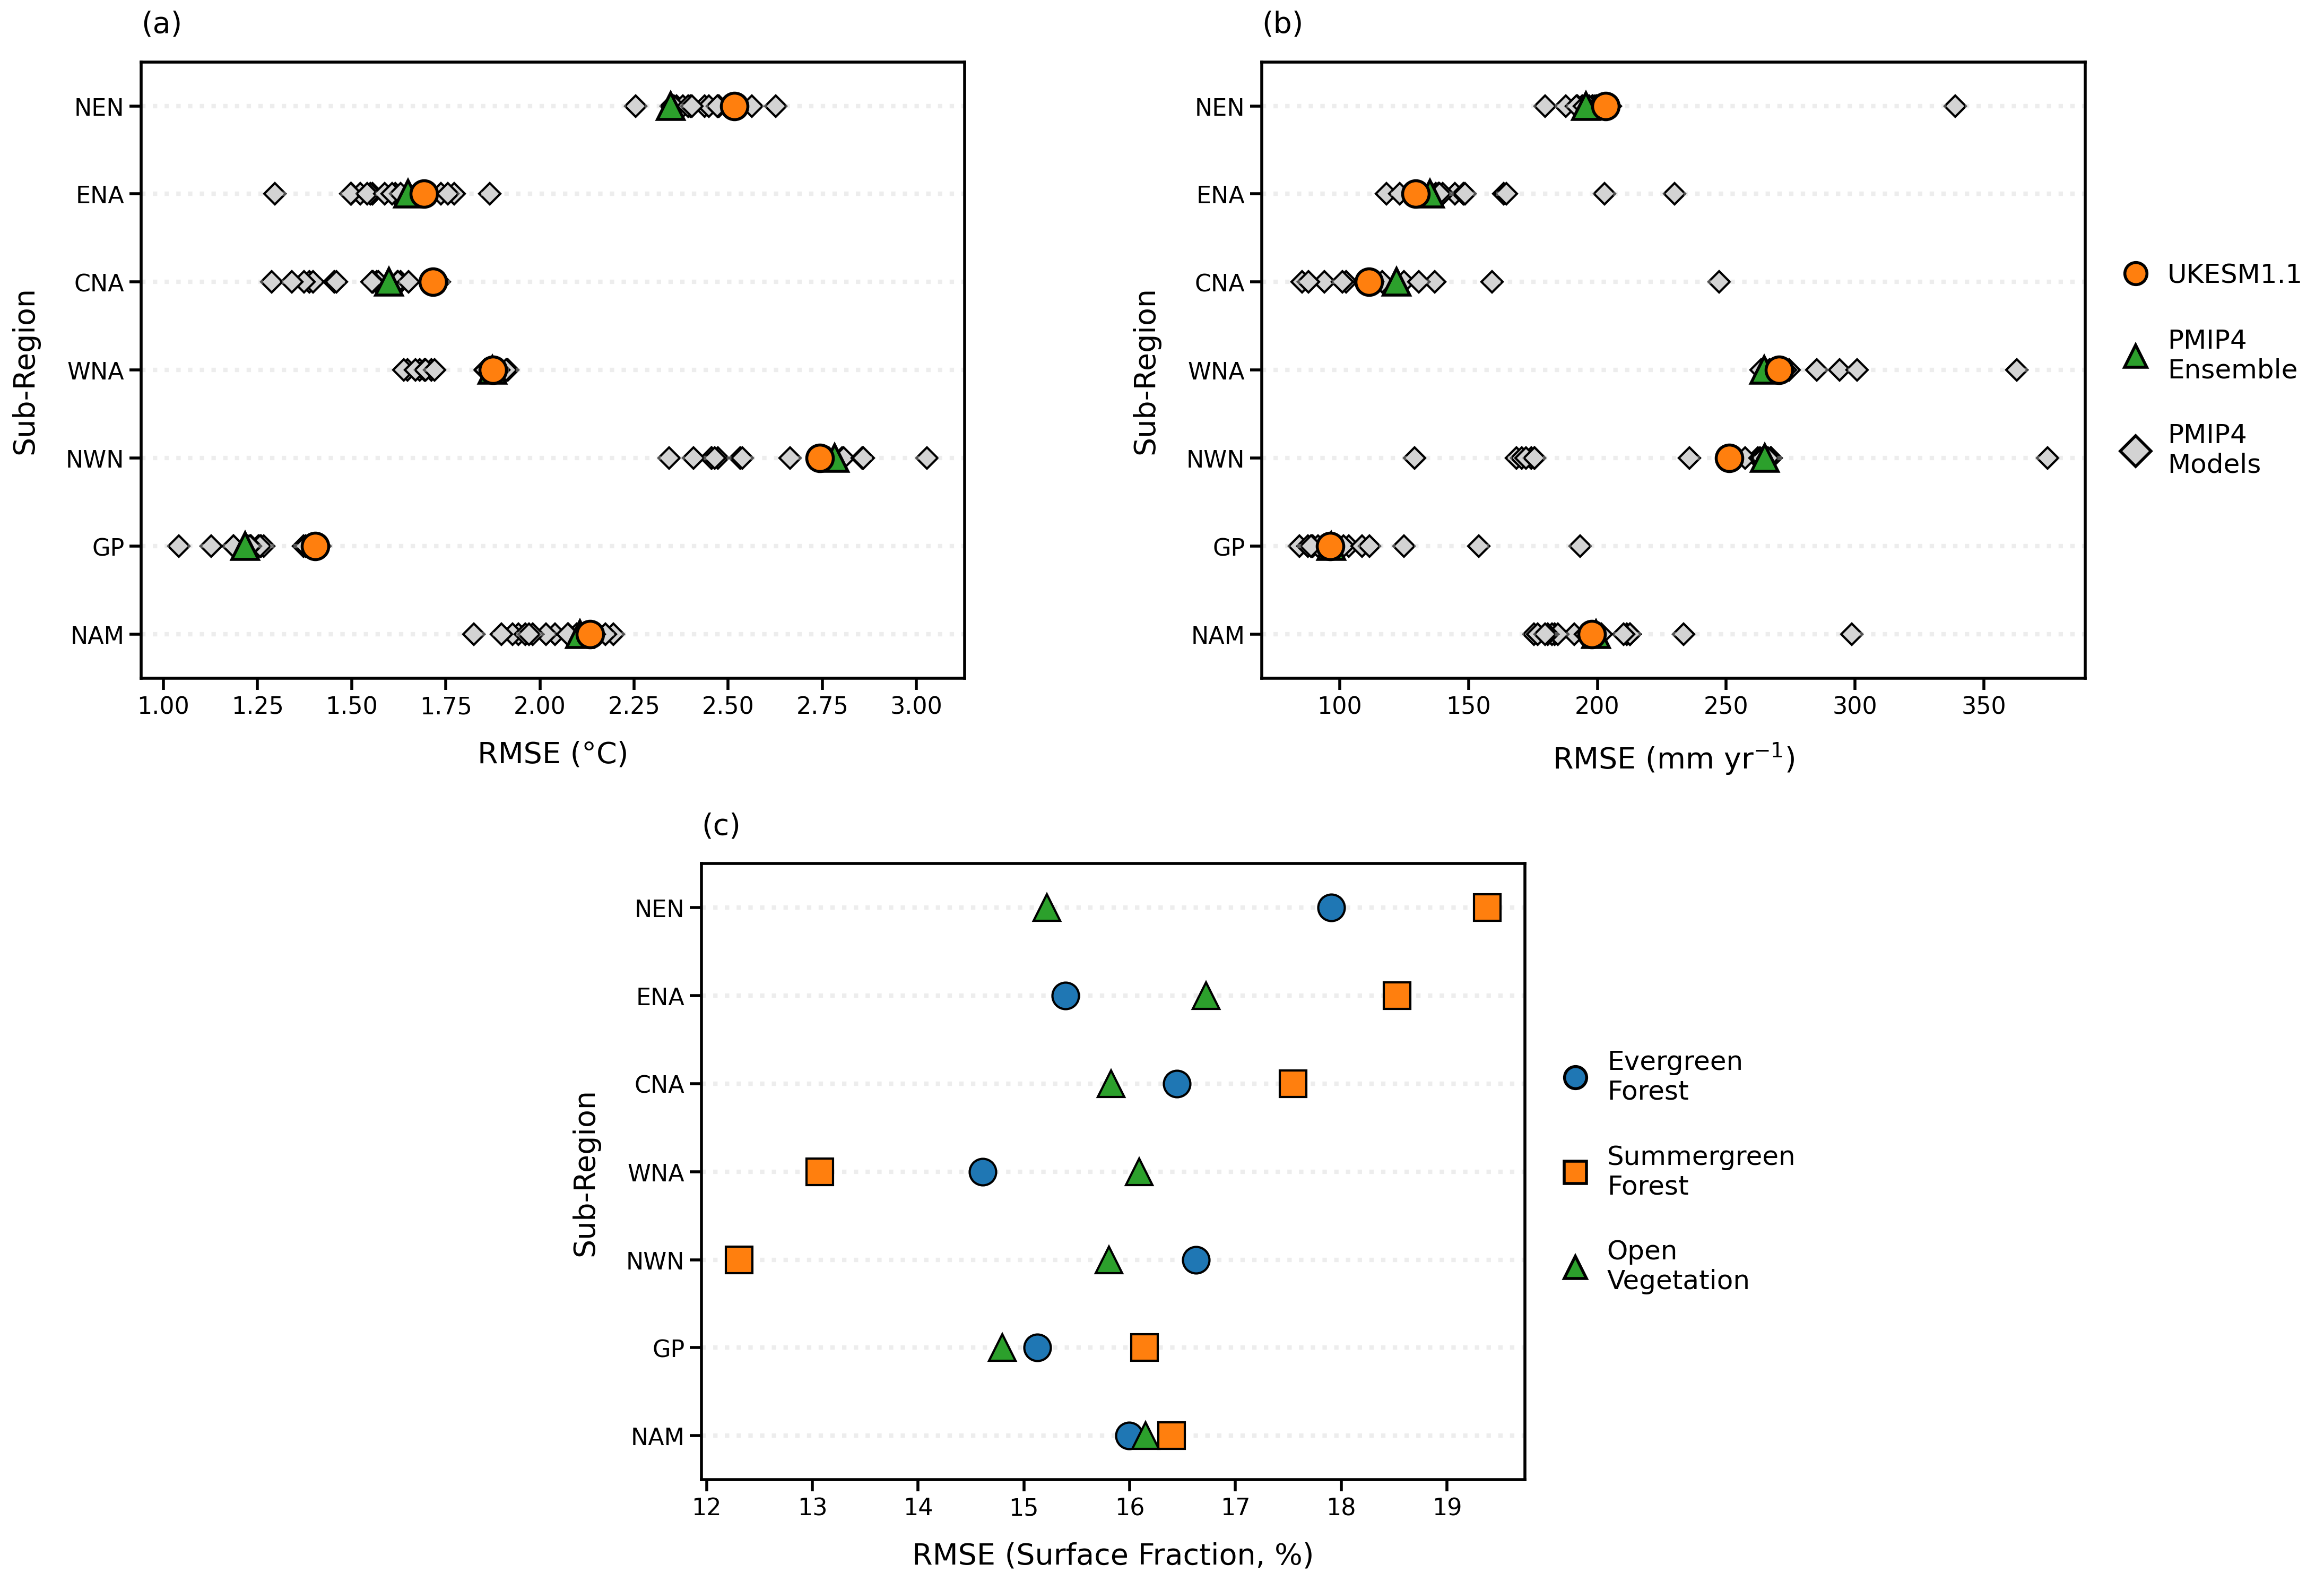

In [ ]:
#------------------------------------------------------------
# Fig. S3: RMSE Scores for UKESM + PMIP4
#------------------------------------------------------------

vars = ["tas", "pr", "veg"]
xlabels = ["RMSE (°C)", r"RMSE (mm $\mathregular{yr^{-1}}$)", "RMSE (Surface Fraction, %)"]
plotlabels = ["a", "b", "c"]
subregions = ["NAM", "GP", "NWN", "WNA", "CNA", "ENA", "NEN"]

fig = plt.figure(figsize=(22, 15), dpi=200)
gs = gridspec.GridSpec(2, 4)
plots = [gs[0, :2], gs[0, 2:], gs[1, 1:3]]

plot_data = zip(vars, xlabels, plots)

for i, (variable, xlab, plot) in enumerate(plot_data):
    ax = plt.subplot(plot)

    if variable == "veg":
        markers = ["o", "s", "^"]
        colors = ["tab:blue", "tab:orange", "tab:green"]
        labels = ["Evergreen\nForest", "Summergreen\nForest", "Open\nVegetation"]
        
        rmse = pd.read_excel(f"../Data/Proxies/{variable}_rmse_vals.xlsx")
        for ypos, region in enumerate(subregions, start=1):
            vals = rmse[region].values
            ax.axhline(ypos, color="lightgrey", ls="dotted", lw=3, alpha=0.4)
            for x, m, c in zip(vals, markers, colors):
                ax.plot(x, ypos, linestyle="None", marker=m, color=c, ms=18, mew=1.5, mec="black")
        
        lines = [Line2D([0], [0], marker=m, color=c, mec="black", ms=15, mew=2, linestyle="None", label=l) for m, c, l in zip(markers, colors, labels)]
        ax.legend(handles=lines, loc="center left", frameon=False, bbox_to_anchor=(1, 0.5), handletextpad=0.2, fontsize=18, labelspacing=1.5)

    else:
        rmse = pd.read_excel(f"../Data/Proxies/{variable}_rmse_vals.xlsx", sheet_name="Combined")
        rmse = rmse.set_index("Models")
        ukesm_rmse = rmse.loc["UKESM1-1-LL"]
        ensemble_rmse = rmse.loc["PMIP4_Ensemble"]
        pmip4_rmse = rmse.drop(["UKESM1-1-LL", "PMIP4_Ensemble"])

        for ypos, region in enumerate(subregions, start=1):
            ax.axhline(ypos, color="lightgrey", ls="dotted", lw=3, alpha=0.4)

            ax.plot(ukesm_rmse[region], ypos, linestyle="None", marker="o", color="tab:orange", ms=18, mec="black", mew=2, zorder=3)
            ax.plot(ensemble_rmse[region], ypos, linestyle="None", marker="^", color="tab:green", ms=18, mec="black", mew=2, zorder=2)
            
            pmip4_vals = pmip4_rmse[region].values
            for x in pmip4_vals:
                ax.plot(x, ypos, linestyle="None", marker="D", mfc="lightgrey", ms=10, mec="black", mew=1.5, zorder=1)

        if variable == "pr":
            markers = ["o", "^", "D"]
            facecolors = ["tab:orange", "tab:green", "lightgrey"]
            edgecolors = ["black", "black", "black"]
            labels = ["UKESM1.1", "PMIP4\nEnsemble", "PMIP4\nModels"]
            lines = [Line2D([0], [0], marker=m, mfc=mfc, mec=mec, ms=15, mew=2, linestyle="None", label=l) for m, mfc, mec, l in zip(markers, facecolors, edgecolors, labels)]
            ax.legend(handles=lines, loc="center left", frameon=False, bbox_to_anchor=(1, 0.5), handletextpad=0.2, fontsize=18, labelspacing=1.5)

    ax.set_xlabel(xlab, fontsize=20, labelpad=15)
    ax.set_ylabel("Sub-Region", fontsize=20, labelpad=18)
    ax.set_ylim(0.5, len(subregions) + 0.5)
    ax.set_yticks(np.arange(1, len(subregions) + 1))
    ax.set_yticklabels(subregions)    
    ax.spines[["top", "bottom", "left", "right"]].set_linewidth(2)
    ax.tick_params(axis="both", width=2, length=8, labelsize=16)

    ax.set_title(f"({plotlabels[i]})", loc="left", fontsize=20, pad=20)

plt.tight_layout()
gs.update(hspace=0.3)
plt.show()

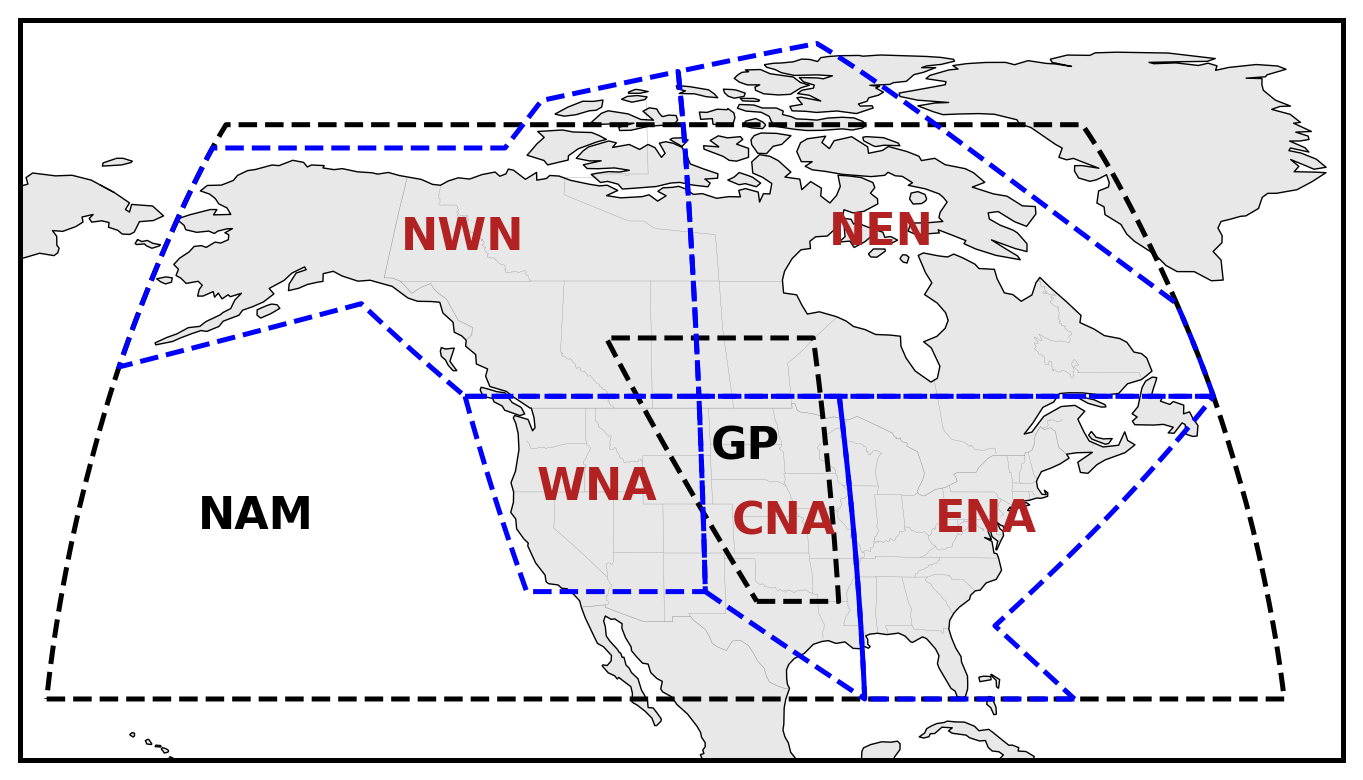

In [ ]:
#------------------------------------------------------------
# Fig. S4: Sub-regions used in study
#------------------------------------------------------------

subregions = ["NAM", "GP", "WNA", "CNA", "ENA", "NWN", "NEN"]

fig = plt.figure(figsize=(8, 4), dpi=200)
ax = plt.subplot(projection=ccrs.Robinson(central_longitude=-112.5))
umplt.plotBaseMap(ax, [-170, -45, 20, 90], coastlw=0.5, land=True, landcol="lightgray", landalph=0.5, spinelw=1.8)
ax.add_feature(cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='grey'), linewidth=0.1, zorder=1)

for region_name in subregions:
    if region_name in ["NAM", "GP"]:
        region = umplt.umRegion(region_name)
        text_kws = {"fontsize": 16, "color": "black", "bbox": None, "fontweight": "bold"}
        line_kws = {"color": "black", "linestyle": "dashed", "linewidth": 1.8}
    else:
        region = rm.defined_regions.ar6.all[[region_name]]
        text_kws = {"fontsize": 16, "color": "firebrick", "bbox": None, "fontweight": "bold"}
        line_kws = {"color": "blue", "linestyle": "dashed", "linewidth": 1.8}
        
    if region_name == "NAM":
        text_kws["position"] = (-150, 40)

    region.plot(ax=ax, line_kws=line_kws, text_kws=text_kws, add_coastlines=False, label="abbrev")

plt.tight_layout()
plt.show()